In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import plotly.graph_objects as go

In [2]:
PARQ_PATH = Path('../sample_dataset/processed_data/parquets/20220730-0002.parquet')
DC_OFFSET = 1.9  # Volts

In [3]:
# Load the parquet file into a DataFrame
df = pd.read_parquet(PARQ_PATH)
df.columns = df.columns.astype('int16') # parquet stores column names as strings; we want integers

num_initial_signals = df.shape[0]
print(f"\x1b[1;36m{num_initial_signals}\x1b[0m signals loaded.")

5000 signals loaded.


In [4]:
# Drop any signals that have missing or infinite values
df = df.replace([np.inf, -np.inf], np.nan).dropna(how='any')
num_missing_signals = num_initial_signals - df.shape[0]
print(f"Removed \x1b[1;31m{num_missing_signals}\x1b[0m signals with missing or infinite values.")

Removed 58 signals with missing or infinite values.


In [5]:
# Subtract DC offset
df = df - DC_OFFSET
# Invert signals
df = -1 * df

In [6]:
# Offset dataframe upwards by global minimum
# TODO: check if this is necessary
df = df + abs(min(df.min()))

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
b0002s0001,0.031800,0.029664,0.034974,0.027528,0.028626,0.027528,0.032838,0.036012,0.034974,0.030702,...,0.032838,0.032838,0.031800,0.030702,0.030702,0.028626,0.033937,0.031800,0.030702,0.032838
b0002s0002,0.026490,0.032838,0.029664,0.029664,0.034974,0.022278,0.036012,0.033937,0.033937,0.031800,...,0.030702,0.032838,0.037110,0.034974,0.037110,0.039186,0.031800,0.029664,0.031800,0.036012
b0002s0003,0.026490,0.038148,0.032838,0.029664,0.034974,0.034974,0.030702,0.033937,0.028626,0.036012,...,0.032838,0.043458,0.044496,0.040284,0.042360,0.047670,0.042360,0.034974,0.029664,0.039186
b0002s0004,0.028626,0.030702,0.029664,0.029664,0.030702,0.027528,0.033937,0.032838,0.026490,0.034974,...,0.027528,0.028626,0.032838,0.031800,0.030702,0.032838,0.033937,0.026490,0.032838,0.032838
b0002s0005,0.029664,0.030702,0.034974,0.027528,0.036012,0.029664,0.032838,0.028626,0.031800,0.033937,...,0.031800,0.030702,0.031800,0.026490,0.033937,0.031800,0.028626,0.033937,0.031800,0.028626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b0002s4996,0.025452,0.029664,0.031800,0.032838,0.027528,0.031800,0.031800,0.032838,0.033937,0.028626,...,0.032838,0.033937,0.032838,0.027528,0.038148,0.041322,0.042360,0.034974,0.033937,0.030702
b0002s4997,0.030702,0.032838,0.029664,0.027528,0.029664,0.031800,0.026490,0.029664,0.028626,0.032838,...,0.032838,0.030702,0.033937,0.026490,0.034974,0.028626,0.034974,0.032838,0.033937,0.033937
b0002s4998,0.031800,0.024354,0.031800,0.033937,0.031800,0.036012,0.033937,0.028626,0.032838,0.029664,...,0.042360,0.031800,0.033937,0.034974,0.044496,0.030702,0.040284,0.029664,0.036012,0.038148
b0002s4999,0.030702,0.030702,0.034974,0.029664,0.028626,0.037110,0.030702,0.029664,0.026490,0.030702,...,0.034974,0.036012,0.026490,0.038148,0.031800,0.031800,0.038148,0.039186,0.030702,0.032838


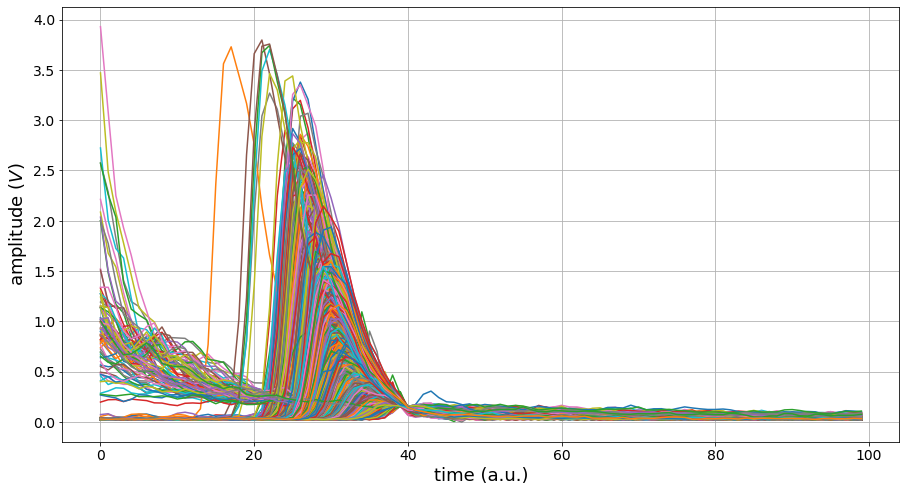

In [23]:
# Plot signals
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df.T
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

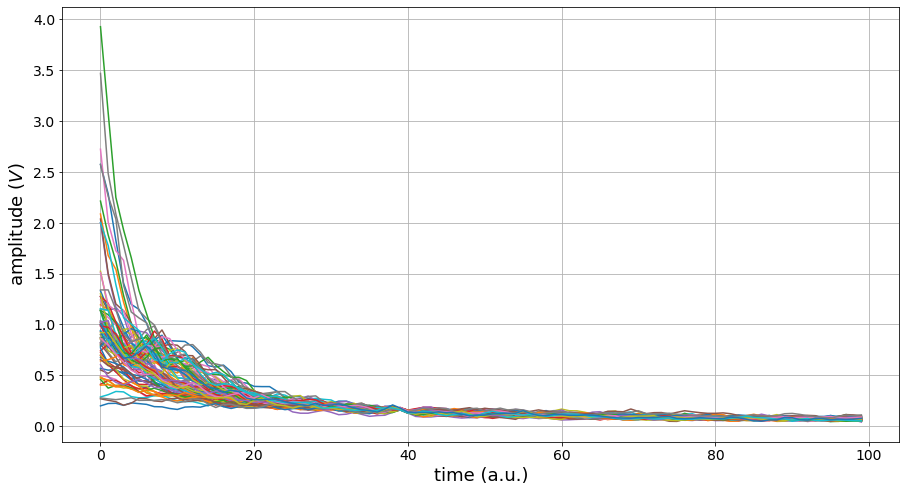

In [18]:
filt = (df[0] < 0.15)
bad_filt = (df[0] >= 0.15)
df_dirty = df[bad_filt]

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_dirty.T
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

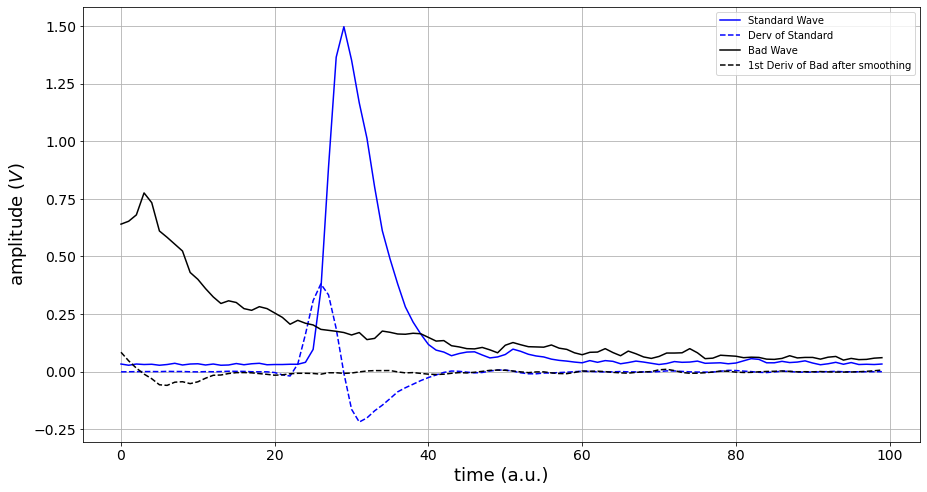

In [17]:
import scipy.signal as sps

# IMPORTANT ONES TO CHECK IN `df_dirty`:
# 51

start = 51
stop = start + 2
win_len = 10
po = 3
der = 1


clean_idx = 10
dirty_idx = 51
df_smooth = sps.savgol_filter(
    df_dirty.iloc[dirty_idx,:], 
    window_length=win_len, 
    polyorder=po, 
    deriv=der
)

df_smooth_og = sps.savgol_filter(
    df.iloc[clean_idx,:], 
    window_length=win_len, 
    polyorder=po, 
    deriv=der
)

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df.iloc[clean_idx,:].T, 'b-', label='Standard Wave'
)

ax.plot(
    df_smooth_og.T, 'b--', label='Derv of Standard'
)


ax.plot(
    df_dirty.iloc[dirty_idx,:].T, 'k-', label='Bad Wave'
)

ax.plot(
    df_smooth, 'k--', label='1st Deriv of Bad after smoothing'
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.legend()
plt.show()

# Gaussian Fitting


In [25]:
import scipy as sp
import scipy.stats as stats
from scipy import optimize

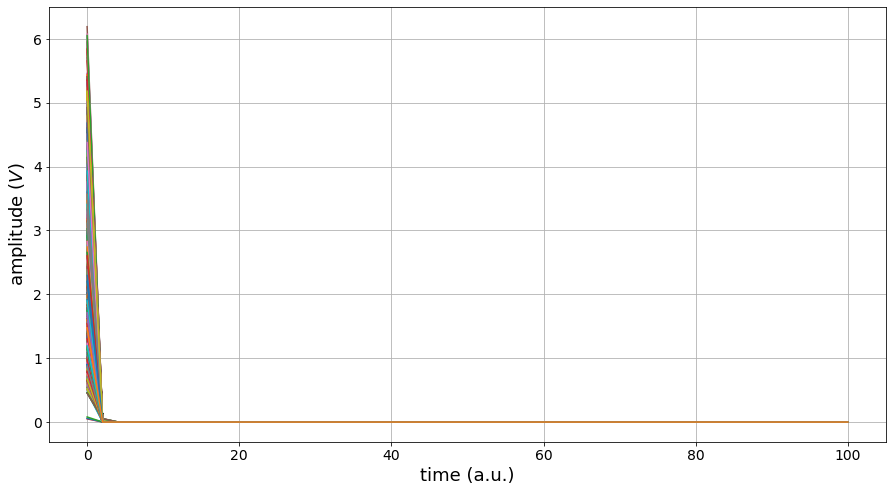

In [26]:
data = df[0:5].T
results = df.apply(stats.norm.fit, axis=1)

fig, ax = plt.subplots(figsize=(15,8))
    
scale = np.linspace(0, data.shape[0])
for res in results: 
    fit = stats.norm.pdf(scale, res[0], res[1])
    ax.plot(scale, fit)
    
ax.grid(visible=True)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

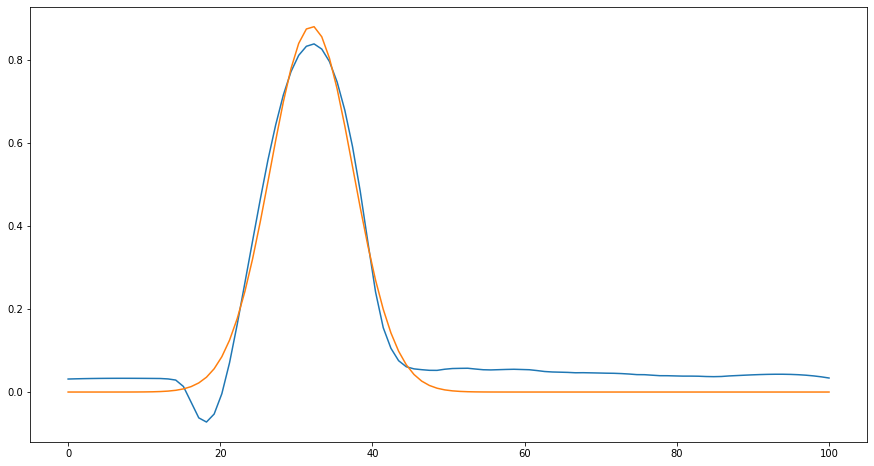

In [34]:
fig, ax = plt.subplots(figsize=(15,8))

data = df.iloc[2,:]  # Try playing with index here! Some work better than others...(eg: index 1 vs 2)
data = sps.savgol_filter(data, window_length=25, polyorder=3)
x = np.linspace(0, data.shape[0], data.shape[0])

def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) / 4 / stddev)**2)

popt, _ = optimize.curve_fit(gaussian, x, data)

plt.plot(x, data)
plt.plot(x, gaussian(x, *popt))

# Smoothing
Using Savitzky-Golay Filter

In [373]:
window_length = 10
polyorder = 3

df_smooth = df.T.apply(
    sps.savgol_filter, args=(window_length, polyorder)
)

df_dirty_smooth = df_smooth[df[bad_filt].index]

## Plot Smoothed Data

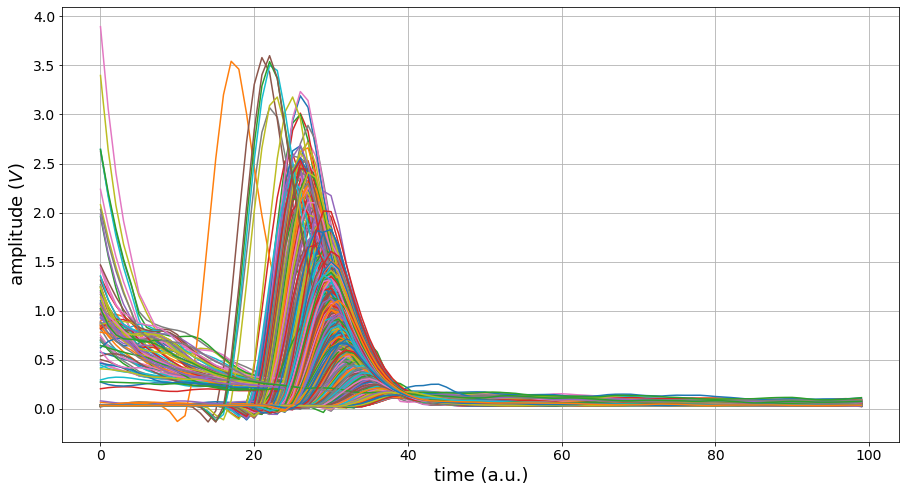

In [374]:
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_smooth
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

In [375]:
def find_peaks(series, prominence=0.1):
    peaks, amplitudes = sps.find_peaks(series, prominence=prominence)
    return peaks, amplitudes['prominences']

packed_vals = df_smooth.apply(find_peaks)
peaks, amplitudes = packed_vals.iloc[0,:], packed_vals.iloc[1,:]
to_drop = [*peaks[peaks.apply( len ) == 0 ].index]
df_smooth_filtered = df_smooth.drop(to_drop, axis=1)
amplitudes = amplitudes.drop(to_drop)
num_missing_signals = num_initial_signals - df_smooth_filtered.shape[1]
print(f"Removed \x1b[1;31m{num_missing_signals}\x1b[0m signals assumed to be bad.")

Removed 147 signals assumed to be bad.


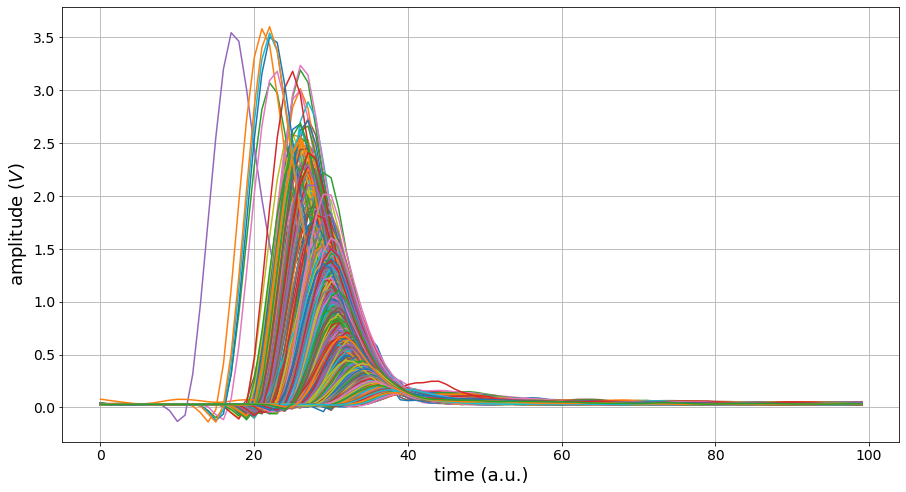

In [376]:
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_smooth_filtered
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

In [377]:
offset = 5
tail_indices = peaks + offset

def sum_tail(series, tail_indices = tail_indices):
    tail_idx = tail_indices[series.name]
    return series.iloc[tail_idx[0]:-1].sum()

sums = df_smooth_filtered.sum()
tail_sum = df_smooth_filtered.apply(sum_tail)

In [378]:
quotients = tail_sum / sums
quotients

b0002s0001    0.477435
b0002s0002    0.475155
b0002s0003    0.331816
b0002s0004    0.393665
b0002s0005    0.454707
                ...   
b0002s4996    0.415413
b0002s4997    0.462173
b0002s4998    0.347693
b0002s4999    0.371459
b0002s5000    0.331745
Length: 4853, dtype: float32

Text(0, 0.5, 'Tail Integral')

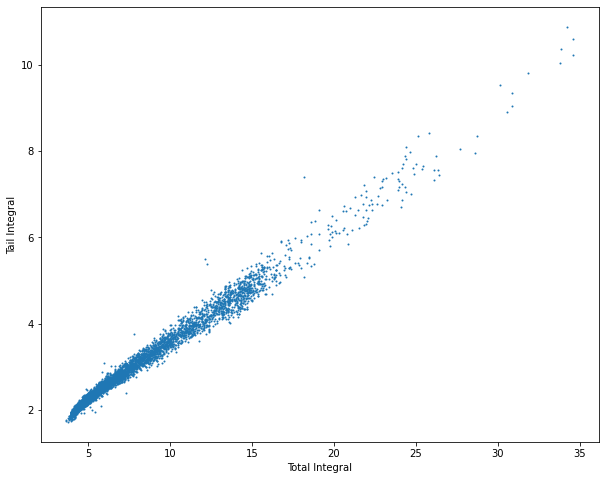

In [372]:
fig, ax = plt.subplots(figsize=(10,8))

ax.plot(sums, tail_sum, 'o', markersize=1)
plt.xlabel('Total Integral')
plt.ylabel('Tail Integral')

# Time Analysis


In [295]:
%%timeit
window_length = 10
polyorder = 3
offset = 5

df_smooth = df.T.apply(
    sps.savgol_filter, args=(window_length, polyorder)
)

def find_peaks(series, prominence=0.1):
    peaks, _ = sps.find_peaks(series, prominence=prominence)
    return peaks

peaks = df_smooth.apply(find_peaks)
to_drop = peaks[peaks.apply( len ) == 0 ].index
df_smooth_filtered = df_smooth.drop([*peaks[peaks.apply( len ) == 0 ].index], axis=1)

tail_indices = peaks + offset

def sum_tail(series, tail_indices = tail_indices):
    tail_idx = tail_indices[series.name]
    return series.iloc[tail_idx[0]:-1].sum()

sums = df_smooth_filtered.sum()
tail_sum = df_smooth_filtered.apply(sum_tail)

3.45 s ± 21.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [380]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
b0002s0001,0.031800,0.029664,0.034974,0.027528,0.028626,0.027528,0.032838,0.036012,0.034974,0.030702,...,0.032838,0.032838,0.031800,0.030702,0.030702,0.028626,0.033937,0.031800,0.030702,0.032838
b0002s0002,0.026490,0.032838,0.029664,0.029664,0.034974,0.022278,0.036012,0.033937,0.033937,0.031800,...,0.030702,0.032838,0.037110,0.034974,0.037110,0.039186,0.031800,0.029664,0.031800,0.036012
b0002s0003,0.026490,0.038148,0.032838,0.029664,0.034974,0.034974,0.030702,0.033937,0.028626,0.036012,...,0.032838,0.043458,0.044496,0.040284,0.042360,0.047670,0.042360,0.034974,0.029664,0.039186
b0002s0004,0.028626,0.030702,0.029664,0.029664,0.030702,0.027528,0.033937,0.032838,0.026490,0.034974,...,0.027528,0.028626,0.032838,0.031800,0.030702,0.032838,0.033937,0.026490,0.032838,0.032838
b0002s0005,0.029664,0.030702,0.034974,0.027528,0.036012,0.029664,0.032838,0.028626,0.031800,0.033937,...,0.031800,0.030702,0.031800,0.026490,0.033937,0.031800,0.028626,0.033937,0.031800,0.028626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b0002s4996,0.025452,0.029664,0.031800,0.032838,0.027528,0.031800,0.031800,0.032838,0.033937,0.028626,...,0.032838,0.033937,0.032838,0.027528,0.038148,0.041322,0.042360,0.034974,0.033937,0.030702
b0002s4997,0.030702,0.032838,0.029664,0.027528,0.029664,0.031800,0.026490,0.029664,0.028626,0.032838,...,0.032838,0.030702,0.033937,0.026490,0.034974,0.028626,0.034974,0.032838,0.033937,0.033937
b0002s4998,0.031800,0.024354,0.031800,0.033937,0.031800,0.036012,0.033937,0.028626,0.032838,0.029664,...,0.042360,0.031800,0.033937,0.034974,0.044496,0.030702,0.040284,0.029664,0.036012,0.038148
b0002s4999,0.030702,0.030702,0.034974,0.029664,0.028626,0.037110,0.030702,0.029664,0.026490,0.030702,...,0.034974,0.036012,0.026490,0.038148,0.031800,0.031800,0.038148,0.039186,0.030702,0.032838
